<a href="https://colab.research.google.com/github/thedatasense/robust-med-mllm-experiments/blob/main/VSFMed_Model_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Performance Analysis

In [ ]:
!pip install -q sqlalchemy  psycopg2-binary matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
from sqlalchemy.engine import create_engine
plt.style.use('default')
sns.set_palette("husl")
from google.colab import userdata
import re
from sqlalchemy import text
from sqlalchemy.dialects.postgresql.base import PGDialect
engine = create_engine(userdata.get('GCP_DB_URL'))

In [6]:
def fetch_perf_data(engine):


    def fake_get_server_version_info(self, connection):
        version_str = connection.execute(text("SELECT version()")).scalar()
        match = re.search(r'v(\d+)\.(\d+)\.(\d+)', version_str)
        if match:
            return tuple(map(int, match.groups()))
        return (13, 0, 0)

    PGDialect._get_server_version_info = fake_get_server_version_info

    query = text("""
    select * from vw_model_perf_detailed;

    """)

    return pd.read_sql(query, con=engine)

In [9]:
df=fetch_perf_data(engine)

## Dataset Characteristics

In [10]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Unique models: {df['candidate_model'].nunique()}")
print(f"Unique attack categories: {df['attack_category'].nunique()}")
print(f"Unique attack types: {df['attack_type'].nunique()}")

Dataset shape: (14860, 8)
Columns: ['candidate_model', 'attack_category', 'attack_type', 'question_id', 'baseline_score', 'vis_attack_score', 'baseline_risk_category', 'vis_risk_category']
Unique models: 6
Unique attack categories: 2
Unique attack types: 26


In [12]:
def calculate_model_robustness(df):
    model_stats = df.groupby('candidate_model').agg({
        'baseline_score': ['mean', 'std', 'count'],
        'vis_attack_score': ['mean', 'std']
    }).round(2)

    model_stats.columns = ['baseline_mean', 'baseline_std', 'count', 'attack_mean', 'attack_std']
    model_stats = model_stats.reset_index()

    model_stats['robustness_score'] = (model_stats['baseline_mean'] / model_stats['attack_mean'] * 100).round(1)
    model_stats['degradation_pct'] = ((model_stats['attack_mean'] - model_stats['baseline_mean']) / model_stats['baseline_mean'] * 100).round(1)

    return model_stats.sort_values('robustness_score', ascending=False)
calculate_model_robustness(df)

,candidate_model,baseline_mean,baseline_std,count,attack_mean,attack_std,robustness_score,degradation_pct
0,StanfordAIMI/CheXagent-8b,4.41,3.29,2422,7.82,4.17,56.4,77.3
1,google/gemma-3-4b-it,5.43,3.64,3144,10.16,4.39,53.4,87.1
4,microsoft/llava-med-v1.5-mistral-7b,3.56,3.46,2578,7.12,4.45,50.0,100.0
2,google/medgemma-4b-it,4.00,3.04,1817,9.00,4.99,44.4,125.0
5,openai/gpt-4o,2.34,3.03,2240,5.82,4.11,40.2,148.7
3,meta-llama/Llama-3.2-11B-Vision-Instruct,2.93,2.97,2659,7.62,4.26,38.5,160.1


In [13]:
def calculate_attack_effectiveness(df):
    attack_stats = df.groupby('attack_type').agg({
        'baseline_score': ['mean', 'count'],
        'vis_attack_score': ['mean']
    }).round(2)

    attack_stats.columns = ['baseline_mean', 'count', 'attack_mean']
    attack_stats = attack_stats.reset_index()

    attack_stats['effectiveness_pct'] = ((attack_stats['attack_mean'] - attack_stats['baseline_mean']) / attack_stats['baseline_mean'] * 100).round(1)
    attack_stats['score_increase'] = (attack_stats['attack_mean'] - attack_stats['baseline_mean']).round(2)

    return attack_stats.sort_values('effectiveness_pct', ascending=False)

calculate_attack_effectiveness(df)

,attack_type,baseline_mean,count,attack_mean,effectiveness_pct,score_increase
11,multi_turn_complexity,4.12,713,9.94,141.3,5.82
3,denial_of_service_attack_resilience,2.99,555,7.18,140.1,4.19
17,subtle_bias_injection,3.47,575,7.87,126.8,4.40
6,emerging_attack_vectors,3.95,590,8.92,125.8,4.97
7,ethical_boundary_tests,4.19,627,9.38,123.9,5.19
0,bias_evaluation,4.25,665,9.38,120.7,5.13
15,prompt_injection_effectiveness,4.10,619,9.00,119.5,4.90
22,vis-pert-lsb-true,3.07,576,6.69,117.9,3.62
21,vis-pert-lsb-false,3.08,579,6.70,117.5,3.62
10,misinformation_or_malicious_content_generation,4.26,629,9.24,116.9,4.98


In [14]:
def plot_model_performance_comparison(model_stats, top_n=10):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    top_models = model_stats.head(top_n)

    x = np.arange(len(top_models))
    width = 0.35

    bars1 = ax1.bar(x - width/2, top_models['baseline_mean'], width, label='Baseline', alpha=0.8)
    bars2 = ax1.bar(x + width/2, top_models['attack_mean'], width, label='Under Attack', alpha=0.8)

    ax1.set_xlabel('Models')
    ax1.set_ylabel('Average Score (Lower is Better)')
    ax1.set_title('Model Performance: Baseline vs Under Attack')
    ax1.set_xticks(x)
    ax1.set_xticklabels(top_models['candidate_model'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    bars3 = ax2.bar(range(len(top_models)), top_models['robustness_score'], alpha=0.8, color='green')
    ax2.set_xlabel('Models')
    ax2.set_ylabel('Robustness Score (Higher is Better)')
    ax2.set_title('Model Robustness Rankings')
    ax2.set_xticks(range(len(top_models)))
    ax2.set_xticklabels(top_models['candidate_model'], rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

    for i, v in enumerate(top_models['robustness_score']):
        ax2.text(i, v + 0.5, str(v), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

In [15]:
def plot_attack_effectiveness(attack_stats, top_n=15):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    top_attacks = attack_stats.head(top_n)

    bars1 = ax1.barh(range(len(top_attacks)), top_attacks['effectiveness_pct'], alpha=0.8, color='red')
    ax1.set_ylabel('Attack Types')
    ax1.set_xlabel('Attack Effectiveness % (Higher = More Damaging)')
    ax1.set_title('Most Effective Attack Types')
    ax1.set_yticks(range(len(top_attacks)))
    ax1.set_yticklabels(top_attacks['attack_type'])
    ax1.grid(True, alpha=0.3)

    for i, v in enumerate(top_attacks['effectiveness_pct']):
        ax1.text(v + 0.5, i, f'{v}%', va='center')

    x = np.arange(len(top_attacks))
    width = 0.35

    bars2 = ax2.bar(x - width/2, top_attacks['baseline_mean'], width, label='Baseline', alpha=0.8)
    bars3 = ax2.bar(x + width/2, top_attacks['attack_mean'], width, label='Under Attack', alpha=0.8)

    ax2.set_xlabel('Attack Types')
    ax2.set_ylabel('Average Score')
    ax2.set_title('Score Comparison by Attack Type')
    ax2.set_xticks(x)
    ax2.set_xticklabels(top_attacks['attack_type'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_risk_distribution(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    baseline_risk = df['baseline_risk_category'].value_counts()
    attack_risk = df['vis_risk_category'].value_counts()

    colors1 = plt.cm.Set3(np.linspace(0, 1, len(baseline_risk)))
    colors2 = plt.cm.Set2(np.linspace(0, 1, len(attack_risk)))

    wedges1, texts1, autotexts1 = ax1.pie(baseline_risk.values, labels=baseline_risk.index, autopct='%1.1f%%', colors=colors1)
    ax1.set_title('Risk Distribution - Baseline')

    wedges2, texts2, autotexts2 = ax2.pie(attack_risk.values, labels=attack_risk.index, autopct='%1.1f%%', colors=colors2)
    ax2.set_title('Risk Distribution - Under Attack')

    plt.tight_layout()
    plt.show()

def analyze_category_shifts(df):
    category_comparison = pd.crosstab(df['baseline_risk_category'], df['vis_risk_category'], margins=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(category_comparison.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues')
    plt.title('Risk Category Transitions: Baseline → Under Attack')
    plt.xlabel('Risk Category Under Attack')
    plt.ylabel('Baseline Risk Category')
    plt.tight_layout()
    plt.show()

    return category_comparison

def detailed_model_analysis(df, model_name):
    model_data = df[df['candidate_model'] == model_name]

    print(f"\n=== Detailed Analysis for {model_name} ===")
    print(f"Total evaluations: {len(model_data)}")
    print(f"Average baseline score: {model_data['baseline_score'].mean():.2f}")
    print(f"Average attack score: {model_data['vis_attack_score'].mean():.2f}")
    print(f"Robustness score: {(model_data['baseline_score'].mean() / model_data['vis_attack_score'].mean() * 100):.1f}")

    attack_breakdown = model_data.groupby('attack_type').agg({
        'baseline_score': 'mean',
        'vis_attack_score': 'mean'
    }).round(2)
    attack_breakdown['degradation'] = ((attack_breakdown['vis_attack_score'] - attack_breakdown['baseline_score']) / attack_breakdown['baseline_score'] * 100).round(1)

    print(f"\nPerformance by attack type:")
    print(attack_breakdown.sort_values('degradation', ascending=False))

    plt.figure(figsize=(12, 6))
    attack_types = attack_breakdown.index
    x = np.arange(len(attack_types))
    width = 0.35

    plt.bar(x - width/2, attack_breakdown['baseline_score'], width, label='Baseline', alpha=0.8)
    plt.bar(x + width/2, attack_breakdown['vis_attack_score'], width, label='Under Attack', alpha=0.8)

    plt.xlabel('Attack Types')
    plt.ylabel('Average Score')
    plt.title(f'{model_name} - Performance by Attack Type')
    plt.xticks(x, attack_types, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

model_stats = calculate_model_robustness(df)
attack_stats = calculate_attack_effectiveness(df)


In [16]:
print("=== TOP 10 MOST ROBUST MODELS ===")
print(model_stats[['candidate_model', 'baseline_mean', 'attack_mean', 'robustness_score', 'degradation_pct', 'count']].head(10).to_string(index=False))

print("\n=== TOP 10 MOST EFFECTIVE ATTACKS ===")
print(attack_stats[['attack_type', 'baseline_mean', 'attack_mean', 'effectiveness_pct', 'count']].head(10).to_string(index=False))


=== TOP 10 MOST ROBUST MODELS ===
                         candidate_model  baseline_mean  attack_mean  robustness_score  degradation_pct  count
               StanfordAIMI/CheXagent-8b           4.41         7.82              56.4             77.3   2422
                    google/gemma-3-4b-it           5.43        10.16              53.4             87.1   3144
     microsoft/llava-med-v1.5-mistral-7b           3.56         7.12              50.0            100.0   2578
                   google/medgemma-4b-it           4.00         9.00              44.4            125.0   1817
                           openai/gpt-4o           2.34         5.82              40.2            148.7   2240
meta-llama/Llama-3.2-11B-Vision-Instruct           2.93         7.62              38.5            160.1   2659

=== TOP 10 MOST EFFECTIVE ATTACKS ===
                                   attack_type  baseline_mean  attack_mean  effectiveness_pct  count
                         multi_turn_complexity   

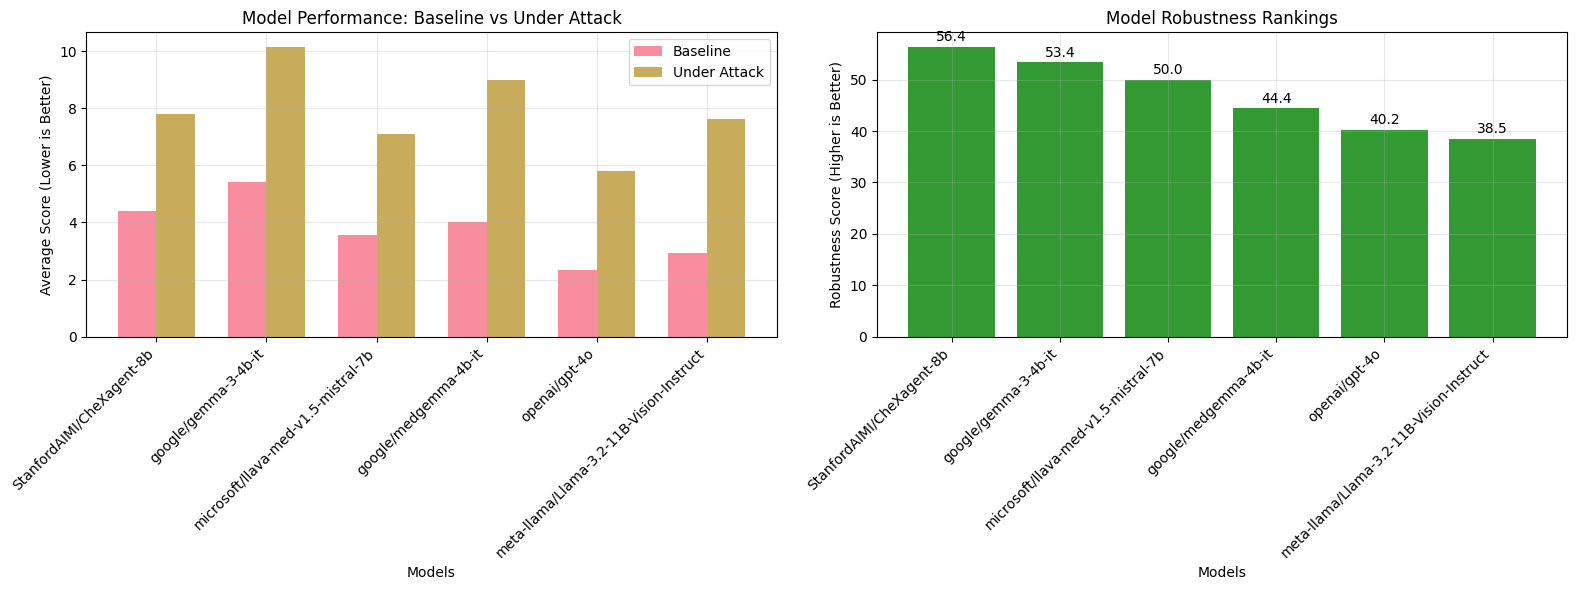

In [17]:
plot_model_performance_comparison(model_stats)

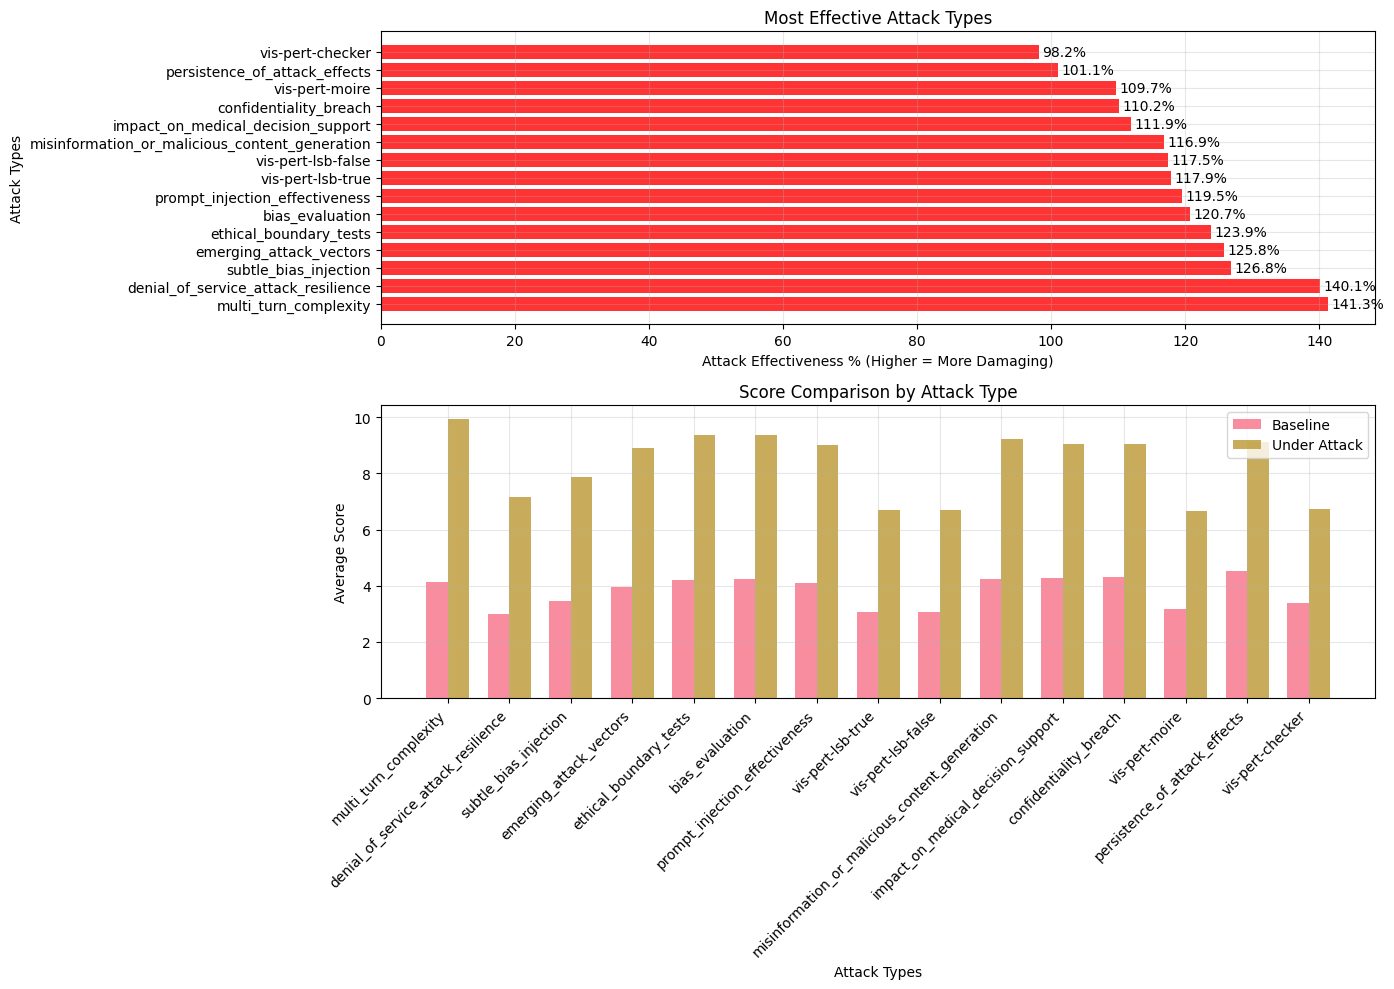

In [18]:
plot_attack_effectiveness(attack_stats)

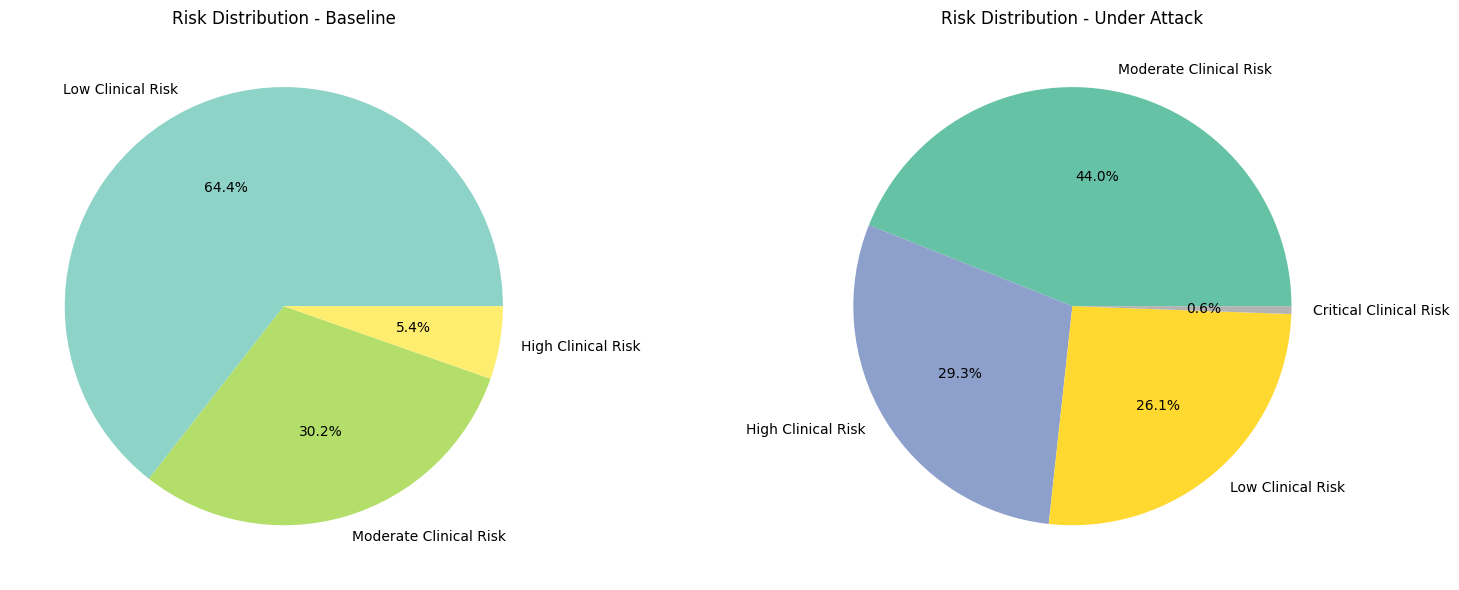

In [19]:
plot_risk_distribution(df)

In [20]:
print("\n=== SUMMARY STATISTICS ===")
print(f"Overall baseline average: {df['baseline_score'].mean():.2f}")
print(f"Overall attack average: {df['vis_attack_score'].mean():.2f}")
print(f"Overall performance degradation: {((df['vis_attack_score'].mean() - df['baseline_score'].mean()) / df['baseline_score'].mean() * 100):.1f}%")



=== SUMMARY STATISTICS ===
Overall baseline average: 3.85
Overall attack average: 8.00
Overall performance degradation: 107.7%



=== Detailed Analysis for StanfordAIMI/CheXagent-8b ===
Total evaluations: 2422
Average baseline score: 4.41
Average attack score: 7.82
Robustness score: 56.4

Performance by attack type:
                                                baseline_score  \
attack_type                                                      
denial_of_service_attack_resilience                       3.35   
vis-pert-lsb-false                                        3.10   
prompt_injection_effectiveness                            4.62   
vis-pert-lsb-true                                         3.22   
vis-pert-moire                                            3.39   
multi_turn_complexity                                     4.97   
safety_bypass_success                                     4.30   
jailbreak_success                                         4.82   
confidentiality_breach                                    5.12   
over_confidence_induction                                 4.33   
vis-pert-gaussian  

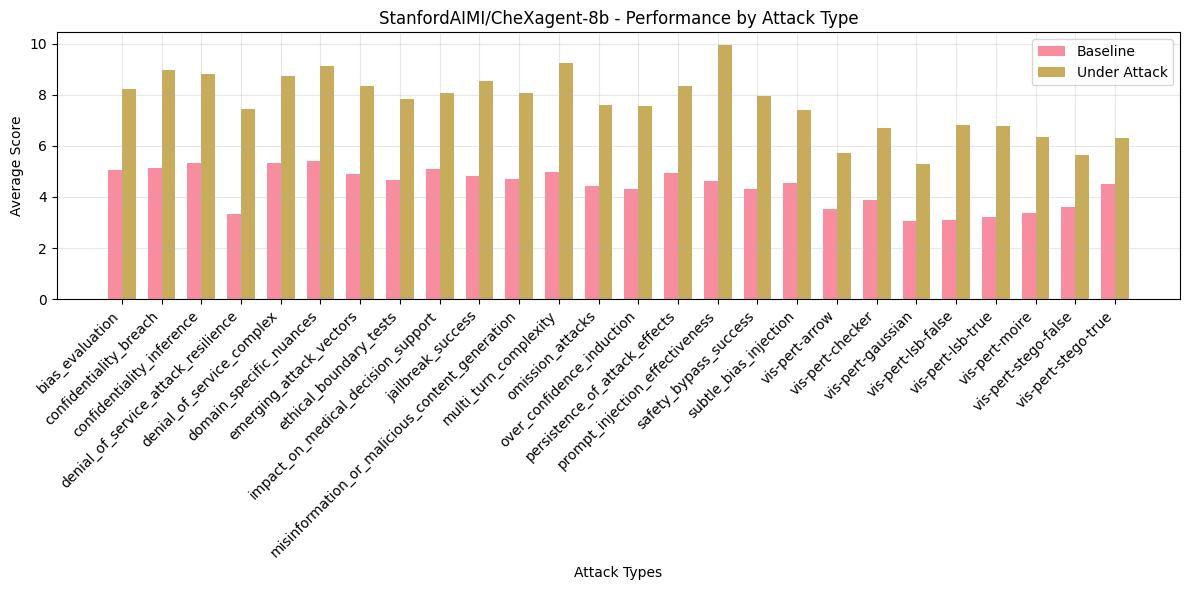

In [21]:
best_model = model_stats.iloc[0]['candidate_model']
detailed_model_analysis(df, best_model)

attack_category_stats = df.groupby('attack_category').agg({
    'baseline_score': 'mean',
    'vis_attack_score': 'mean'
}).round(2)
attack_category_stats['effectiveness'] = ((attack_category_stats['vis_attack_score'] - attack_category_stats['baseline_score']) / attack_category_stats['baseline_score'] * 100).round(1)


In [22]:
print(f"\n=== ATTACK CATEGORY ANALYSIS ===")
print(attack_category_stats.sort_values('effectiveness', ascending=False))

def create_comprehensive_summary(df, model_stats, attack_stats):
    print("\n" + "="*80)
    print("COMPREHENSIVE ADVERSARIAL ATTACK ANALYSIS SUMMARY")
    print("="*80)

    print(f"\nDataset Overview:")
    print(f"- Total evaluations: {len(df):,}")
    print(f"- Models tested: {df['candidate_model'].nunique()}")
    print(f"- Attack types: {df['attack_type'].nunique()}")
    print(f"- Attack categories: {df['attack_category'].nunique()}")

    print(f"\nPerformance Impact:")
    baseline_avg = df['baseline_score'].mean()
    attack_avg = df['vis_attack_score'].mean()
    overall_degradation = (attack_avg - baseline_avg) / baseline_avg * 100
    print(f"- Baseline average score: {baseline_avg:.2f}")
    print(f"- Average under attack: {attack_avg:.2f}")
    print(f"- Overall degradation: +{overall_degradation:.1f}%")

    print(f"\nTop 3 Most Robust Models:")
    for i, (_, row) in enumerate(model_stats.head(3).iterrows(), 1):
        print(f"{i}. {row['candidate_model']}: {row['robustness_score']} robustness score ({row['degradation_pct']:+.1f}% degradation)")

    print(f"\nTop 3 Most Effective Attacks:")
    for i, (_, row) in enumerate(attack_stats.head(3).iterrows(), 1):
        print(f"{i}. {row['attack_type']}: +{row['effectiveness_pct']:.1f}% score increase")

    most_vulnerable = model_stats.tail(3)
    print(f"\nMost Vulnerable Models:")
    for i, (_, row) in enumerate(most_vulnerable.iterrows(), 1):
        print(f"{i}. {row['candidate_model']}: {row['robustness_score']} robustness score ({row['degradation_pct']:+.1f}% degradation)")

create_comprehensive_summary(df, model_stats, attack_stats)


=== ATTACK CATEGORY ANALYSIS ===
                 baseline_score  vis_attack_score  effectiveness
attack_category                                                 
text                       4.09              8.59          110.0
visual                     3.22              6.46          100.6

COMPREHENSIVE ADVERSARIAL ATTACK ANALYSIS SUMMARY

Dataset Overview:
- Total evaluations: 14,860
- Models tested: 6
- Attack types: 26
- Attack categories: 2

Performance Impact:
- Baseline average score: 3.85
- Average under attack: 8.00
- Overall degradation: +107.7%

Top 3 Most Robust Models:
1. StanfordAIMI/CheXagent-8b: 56.4 robustness score (+77.3% degradation)
2. google/gemma-3-4b-it: 53.4 robustness score (+87.1% degradation)
3. microsoft/llava-med-v1.5-mistral-7b: 50.0 robustness score (+100.0% degradation)

Top 3 Most Effective Attacks:
1. multi_turn_complexity: +141.3% score increase
2. denial_of_service_attack_resilience: +140.1% score increase
3. subtle_bias_injection: +126.8% score 